# Module 2 — 矩陣運算與座標轉換

> **對應程度**：高中矩陣初步 → 大學線代入門

矩陣是工程數學的「萬用工具」。從機器手臂的運動控制、橋梁的結構分析，到手機相機的影像處理，幾乎所有工程計算的核心都是矩陣運算。本模組將帶你從最基本的矩陣概念出發，逐步建立起完整的矩陣工具箱。

本模組涵蓋：
1. **矩陣基礎**：什麼是矩陣？特殊矩陣有哪些？
2. **矩陣乘法與旋轉**：為什麼順序很重要？機器手臂怎麼用矩陣乘法？
3. **轉置矩陣與對稱性**：對稱矩陣和牛頓第三定律有什麼關係？
4. **行列式**：面積/體積的縮放因子，以及如何判斷三力共面
5. **逆矩陣**：如何「撤銷」一個變換？感測器校正實例
6. **特殊矩陣總覽**：各類特殊矩陣在工程中的應用與計算優勢

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.linalg_utils import (
    rotation_matrix_2d, rotation_matrix_3d, homogeneous_transform_2d,
    determinant_2x2, determinant_3x3, inverse_2x2
)
from src.visualizer import plot_matrix_heatmap, set_style

set_style()
print('Module 2 載入完成！')

Module 2 載入完成！


---
## 2.1 矩陣基礎

### 原理（Principle）

**矩陣**（Matrix）是一個由數字排列成的矩形陣列，寫成 $m \times n$ 的形式，其中 $m$ 是列數、$n$ 是行數。例如一個 $2 \times 3$ 矩陣：

$$A = \begin{bmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \end{bmatrix}$$

矩陣不只是數字表格——它**代表一種線性轉換**。當我們把一個向量 $\mathbf{v}$ 乘上矩陣 $A$，得到的 $A\mathbf{v}$ 是一個新的向量，這代表 $\mathbf{v}$ 經過「旋轉、縮放、剪切」等操作後的結果。

幾種重要的特殊矩陣：
- **單位矩陣** $I$：對角線為 1，其餘為 0。乘上任何向量不改變它，就像數字的「1」。$I\mathbf{v} = \mathbf{v}$
- **零矩陣** $O$：所有元素為 0。乘上任何向量都得零向量，就像數字的「0」。$O\mathbf{v} = \mathbf{0}$
- **對角矩陣** $D = \text{diag}(d_1, d_2, \dots, d_n)$：只有對角線有值。它對每個軸做獨立的縮放——$d_i$ 就是第 $i$ 軸的縮放因子。

### 直覺理解（Intuition）

想像你在一張方格紙上畫了一個箭頭（向量）。矩陣就像一組「指令」，告訴你怎麼變形這張方格紙——你可以拉伸它、旋轉它、壓扁它。方格紙上的每個箭頭都會跟著一起變形。

- **單位矩陣**就是「什麼都不做」的指令
- **對角矩陣** $\text{diag}(2, 3)$ 就是「水平方向拉長 2 倍，垂直方向拉長 3 倍」

### 實際例子（Real-world Examples）

1. **影像像素**：一張 $1920 \times 1080$ 的照片就是一個矩陣，每個元素代表一個像素的亮度值（0–255）。彩色照片則是三個矩陣疊在一起（R、G、B 三色各一個）。

2. **試算表 / 資料表**：Excel 中一張有 100 列、5 欄的資料表可以看成一個 $100 \times 5$ 的矩陣。每列代表一筆資料，每欄代表一個特徵。

3. **遊戲角色變換**：3D 遊戲中，角色的位置、旋轉、縮放全都用一個 $4 \times 4$ 的矩陣來表示。每一幀畫面，GPU 要對數百萬個頂點做矩陣乘法。

### 為什麼重要（Why It Matters）

矩陣是工程數學最核心的工具。在機械工程中，**應力張量**是矩陣；在電機工程中，**電路的阻抗矩陣**描述了各節點間的關係；在資料科學中，**所有的機器學習模型**本質上都是矩陣運算。掌握矩陣，就等於掌握了工程計算的共通語言。

單位矩陣 I =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

對角矩陣 D = diag(1,2,3) =
[[1 0 0]
 [0 2 0]
 [0 0 3]]


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/408220777.py:16: UserWarning: Glyph 21934 (\N{CJK UNIFIED IDEOGRAPH-55AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/408220777.py:16: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/408220777.py:16: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/408220777.py:16: UserWarning: Glyph 38499 (\N{CJK UNIFIED IDEOGRAPH-9663}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/408220777.py:16: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6

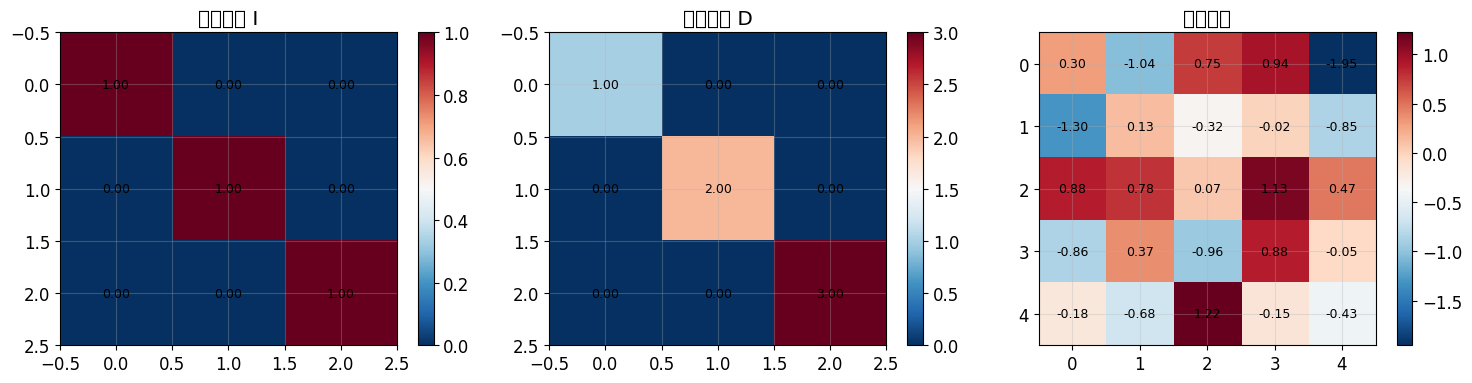

In [2]:
# 建立各類特殊矩陣
I = np.eye(3)           # 單位矩陣
Z = np.zeros((3, 3))    # 零矩陣
D = np.diag([1, 2, 3])  # 對角矩陣

print('單位矩陣 I =')
print(I)
print(f'\n對角矩陣 D = diag(1,2,3) =')
print(D)

# 矩陣視覺化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mat, title in zip(axes, [I, D, np.random.default_rng(42).normal(size=(5,5))],
                          ['單位矩陣 I', '對角矩陣 D', '隨機矩陣']):
    plot_matrix_heatmap(mat, title=title, ax=ax)
plt.tight_layout()
plt.show()

---
## 2.2 矩陣乘法與旋轉

### 原理（Principle）

矩陣乘法是線性代數中最重要的運算。給定 $A$ 是 $m \times n$ 矩陣、$B$ 是 $n \times p$ 矩陣，乘積 $C = AB$ 是 $m \times p$ 矩陣，其元素為：

$$C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}$$

**關鍵性質：矩陣乘法不滿足交換律！** 一般而言 $AB \neq BA$。

為什麼不可交換？因為矩陣乘法代表「依序執行兩個轉換」。$AB$ 表示「先做 $B$ 的轉換，再做 $A$ 的轉換」。順序不同，結果就不同——就像你先穿襪子再穿鞋子，和先穿鞋子再穿襪子，結果完全不同。

**2D 旋轉矩陣**是最優美的矩陣之一：

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

它有一個特殊性質：**旋轉矩陣之間的乘法恰好等於角度相加**：

$$R(\theta_1) \cdot R(\theta_2) = R(\theta_1 + \theta_2)$$

這是因為三角函數的和角公式：$\cos(\alpha+\beta) = \cos\alpha\cos\beta - \sin\alpha\sin\beta$。

### 直覺理解（Intuition）

想像你站在一塊旋轉平台上，手裡拿著一支雷射筆指向北方。

- $R(30°)$ 表示「平台順時針轉 30°」，雷射筆現在指向北偏東 30°
- 再乘 $R(45°)$ 表示「再轉 45°」，雷射筆現在指向北偏東 75°
- 所以 $R(30°) \times R(45°) = R(75°)$

但如果你把「旋轉」和「縮放」混在一起就不一樣了。想像先把一張圖片放大 2 倍再旋轉 90°，跟先旋轉 90° 再放大 2 倍——雖然最終大小一樣，但如果放大的比例不均勻（例如水平放大 2 倍、垂直放大 1 倍），順序就會影響最終形狀。

### 實際例子：機器手臂正向運動學（Forward Kinematics）

考慮一個 2 自由度（2-DOF）的平面機器手臂：
- **第一段臂**長 $L_1 = 1.0$ m，從基座旋轉角度 $\theta_1 = 45°$
- **第二段臂**長 $L_2 = 0.8$ m，相對第一段再旋轉 $\theta_2 = 30°$

末端效應器（End Effector）的位置可以用矩陣乘法求得：

$$\mathbf{p}_{end} = \begin{bmatrix} L_1\cos\theta_1 + L_2\cos(\theta_1+\theta_2) \\ L_1\sin\theta_1 + L_2\sin(\theta_1+\theta_2) \end{bmatrix}$$

這裡每個關節的旋轉就是一個旋轉矩陣，**整條手臂的姿態就是所有旋轉矩陣依序相乘的結果**。工業上 6 軸機器手臂會用 6 個 $4 \times 4$ 齊次變換矩陣連乘來計算末端位置。

### 齊次座標（Homogeneous Coordinates）

在一般的 $2 \times 2$ 矩陣中，我們只能表示旋轉、縮放、剪切——**無法表示平移**。為了統一處理，我們引入齊次座標，把 2D 點 $(x, y)$ 擴展為 $(x, y, 1)$，使用 $3 \times 3$ 矩陣：

$$H = \begin{bmatrix} \cos\theta & -\sin\theta & t_x \\ \sin\theta & \cos\theta & t_y \\ 0 & 0 & 1 \end{bmatrix}$$

這樣一個矩陣就能同時做旋轉 + 平移，大幅簡化機器人學和電腦圖學的計算。

### 為什麼重要（Why It Matters）

- **機器人學**：正向運動學 / 逆向運動學的核心就是矩陣連乘
- **電腦圖學**：GPU 每秒要做數十億次矩陣乘法來渲染 3D 場景
- **控制工程**：狀態空間模型 $\mathbf{x}_{k+1} = A\mathbf{x}_k + B\mathbf{u}_k$ 完全基於矩陣乘法
- **結構工程**：有限元素法的全域剛度矩陣由各元素矩陣組合而成

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26059 (\N{CJK UNIFIED IDEOGRAPH-65CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

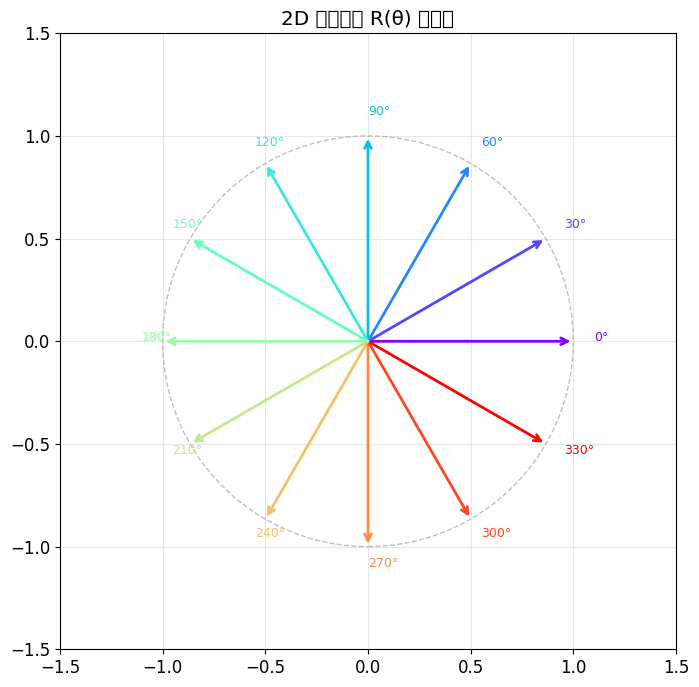

In [3]:
# 2D 旋轉動畫：向量繞原點旋轉
v = np.array([1, 0])  # 初始向量
thetas = np.linspace(0, 2*np.pi, 13)[:-1]  # 每 30° 一個

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, len(thetas)))

for theta, color in zip(thetas, colors):
    R = rotation_matrix_2d(theta)
    v_rotated = R @ v
    ax.annotate('', xy=v_rotated, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(v_rotated[0]*1.1, v_rotated[1]*1.1,
            f'{np.degrees(theta):.0f}°', fontsize=9, color=color)

circle = plt.Circle((0, 0), 1, fill=False, color='gray', ls='--', alpha=0.5)
ax.add_patch(circle)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title('2D 旋轉矩陣 R(θ) 的作用')
ax.grid(True, alpha=0.3)
plt.show()

In [4]:
# 驗證：R(θ₁)·R(θ₂) = R(θ₁+θ₂)
theta1, theta2 = np.pi/6, np.pi/4
R1 = rotation_matrix_2d(theta1)
R2 = rotation_matrix_2d(theta2)
R_product = R1 @ R2
R_sum = rotation_matrix_2d(theta1 + theta2)

print(f'R({np.degrees(theta1):.0f}°) × R({np.degrees(theta2):.0f}°) =')
print(R_product)
print(f'\nR({np.degrees(theta1+theta2):.0f}°) =')
print(R_sum)
print(f'\n一致: {np.allclose(R_product, R_sum)} ✓')

R(30°) × R(45°) =
[[ 0.25881905 -0.96592583]
 [ 0.96592583  0.25881905]]

R(75°) =
[[ 0.25881905 -0.96592583]
 [ 0.96592583  0.25881905]]

一致: True ✓


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/645498548.py:47: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/645498548.py:47: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/645498548.py:47: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/645498548.py:47: UserWarning: Glyph 33218 (\N{CJK UNIFIED IDEOGRAPH-81C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/645498548.py:47: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33218 (\N{CJK UNIFIED IDEOGRAPH-81C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

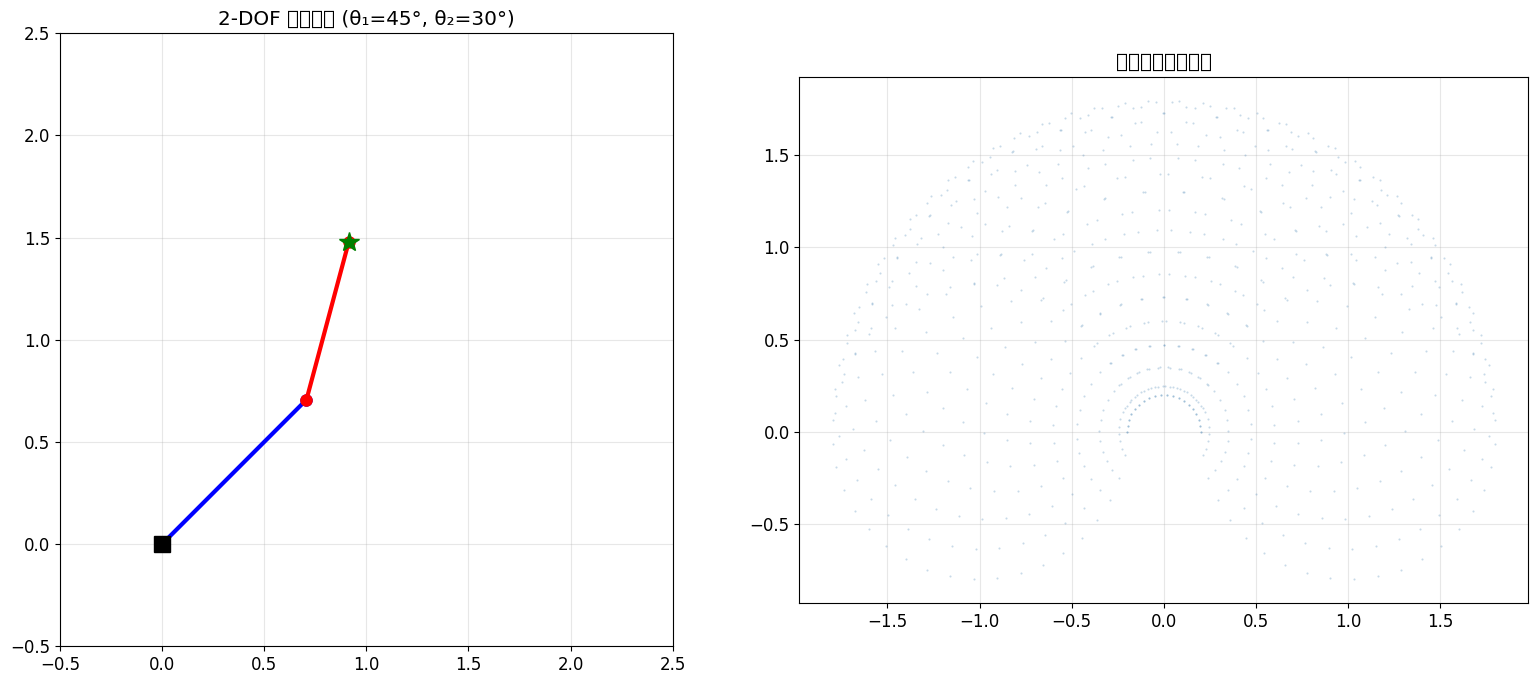

In [5]:
# 2-DOF 機器手臂正向運動學
L1, L2 = 1.0, 0.8  # 臂長
theta1_range = np.radians(45)   # 第一關節角
theta2_range = np.radians(30)   # 第二關節角

def forward_kinematics_2dof(theta1, theta2, L1, L2):
    """2-DOF 正向運動學"""
    # 關節 1 位置
    p1 = np.array([L1 * np.cos(theta1), L1 * np.sin(theta1)])
    # 末端位置 = 兩段旋轉的矩陣乘法
    R1 = rotation_matrix_2d(theta1)
    R2 = rotation_matrix_2d(theta2)
    # 末端相對第一關節的位置
    p2_local = np.array([L2, 0])
    p2 = p1 + R1 @ R2 @ np.array([L2, 0])  # 簡化
    # 正確的末端位置
    p_end = np.array([
        L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2),
        L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    ])
    return np.array([0, 0]), p1, p_end

# 繪製工作空間
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 左圖：單一姿態
base, joint, end = forward_kinematics_2dof(theta1_range, theta2_range, L1, L2)
ax1.plot([base[0], joint[0]], [base[1], joint[1]], 'b-o', lw=3, ms=8)
ax1.plot([joint[0], end[0]], [joint[1], end[1]], 'r-o', lw=3, ms=8)
ax1.plot(base[0], base[1], 'ks', ms=12)  # 基座
ax1.plot(end[0], end[1], 'g*', ms=15)     # 末端
ax1.set_title(f'2-DOF 機器手臂 (θ₁={np.degrees(theta1_range):.0f}°, θ₂={np.degrees(theta2_range):.0f}°)')
ax1.set_xlim(-0.5, 2.5)
ax1.set_ylim(-0.5, 2.5)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# 右圖：工作空間掃描
for t1 in np.linspace(0, np.pi, 20):
    for t2 in np.linspace(-np.pi, np.pi, 40):
        _, _, end = forward_kinematics_2dof(t1, t2, L1, L2)
        ax2.plot(end[0], end[1], '.', color='steelblue', ms=1, alpha=0.3)

ax2.set_title('機器手臂工作空間')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

齊次變換矩陣 H =
[[ 0.70710678 -0.70710678  2.        ]
 [ 0.70710678  0.70710678  1.        ]
 [ 0.          0.          1.        ]]


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 40778 (\N{CJK UNIFIED IDEOGRAPH-9F4A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35722 (\N{CJK UNIFIED IDEOGRAPH-8B8A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25563 (\N{CJK UNIFIED IDEOGRAPH-63DB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

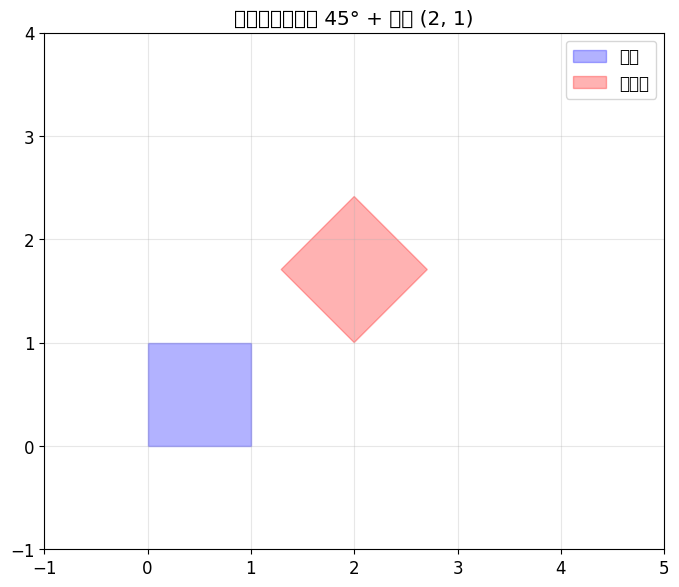

In [6]:
# 齊次座標：平移 + 旋轉 合併為單一矩陣乘法
theta = np.pi / 4  # 旋轉 45°
tx, ty = 2, 1      # 平移

H = homogeneous_transform_2d(theta, tx, ty)
print('齊次變換矩陣 H =')
print(H)

# 變換一個正方形
square = np.array([[0,0,1], [1,0,1], [1,1,1], [0,1,1]]).T  # 齊次座標
transformed = H @ square

fig, ax = plt.subplots(figsize=(8, 8))
orig = Polygon(square[:2].T, fill=True, alpha=0.3, color='blue', label='原始')
trans = Polygon(transformed[:2].T, fill=True, alpha=0.3, color='red', label='變換後')
ax.add_patch(orig)
ax.add_patch(trans)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.set_aspect('equal')
ax.legend(fontsize=12)
ax.set_title(f'齊次變換：旋轉 {np.degrees(theta):.0f}° + 平移 ({tx}, {ty})')
ax.grid(True, alpha=0.3)
plt.show()

---
## 2.3 轉置矩陣與對稱性

### 原理（Principle）

矩陣的**轉置**（Transpose）是把列和行互換。若 $A$ 是 $m \times n$ 矩陣，則 $A^T$ 是 $n \times m$ 矩陣，定義為：

$$(A^T)_{ij} = A_{ji}$$

例如：
$$A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix} \implies A^T = \begin{bmatrix} 1 & 4 \\ 2 & 5 \\ 3 & 6 \end{bmatrix}$$

重要性質：
- $(A^T)^T = A$（轉置兩次回到原來）
- $(A + B)^T = A^T + B^T$
- $(AB)^T = B^T A^T$（注意順序反轉！）
- $(cA)^T = cA^T$

當 $A = A^T$ 時，我們稱 $A$ 為**對稱矩陣**（Symmetric Matrix）。對稱矩陣在工程中無處不在，因為許多物理系統具有「作用力與反作用力」的對稱性。

### 直覺理解（Intuition）

想像一張 Excel 表格，列是「城市」、行也是「城市」，表格中的數字是兩個城市之間的距離。因為從台北到高雄的距離等於從高雄到台北的距離，所以這張表格沿對角線對稱——這就是對稱矩陣。

轉置就像把表格「翻面」——原本的第 $i$ 列變成第 $i$ 行。如果翻面前後看起來一樣，就是對稱矩陣。

### 實際例子：牛頓第三定律與對稱矩陣

**牛頓第三定律**說：$F_{12} = -F_{21}$（A 對 B 的力等於 B 對 A 的力的負值）。

在結構力學中，**剛度矩陣** $K$ 描述了各節點之間的力-位移關係：$\mathbf{F} = K \mathbf{u}$。因為牛頓第三定律，$K_{ij} = K_{ji}$，所以 $K$ 必定是對稱矩陣。

同理，**熱傳導矩陣**也是對稱的。如果節點 A 的溫度變化會影響節點 B，那 B 的溫度變化也會以相同程度影響 A——這就是熱力學中能量守恆的體現。

下面的例子中，我們建構一個一維熱傳導的有限差分矩陣，並驗證其對稱性：

$$K = \begin{bmatrix} 2 & -1 & 0 & \cdots \\ -1 & 2 & -1 & \cdots \\ 0 & -1 & 2 & \cdots \\ \vdots & & & \ddots \end{bmatrix}$$

每個節點受到左右鄰居的影響（$-1$），以及自身的項（$2$）。這個矩陣天生就是對稱的。

### 為什麼重要（Why It Matters）

- **數值計算效率**：對稱矩陣只需儲存上三角（或下三角），記憶體省一半。$n \times n$ 對稱矩陣只需要 $n(n+1)/2$ 個數字，而非 $n^2$ 個。
- **特殊演算法**：對稱矩陣可以使用 Cholesky 分解（比一般 LU 分解快約 2 倍），這在大型有限元素分析中節省大量計算時間。
- **保證實數特徵值**：對稱矩陣的特徵值一定是實數（不會出現複數），這在振動分析中非常重要——特徵值就是系統的自然頻率的平方。
- **應力張量**：材料力學中的應力張量 $\sigma_{ij}$ 是 $3 \times 3$ 對稱矩陣（6 個獨立分量而非 9 個），這是角動量守恆的直接結果。

In [7]:
# 驗證導熱矩陣對稱性
n = 5
K = np.diag(2*np.ones(n)) + np.diag(-np.ones(n-1), 1) + np.diag(-np.ones(n-1), -1)
print('一維熱傳導矩陣 K =')
print(K)
print(f'\nK = K^T ? {np.allclose(K, K.T)} ✓')
print(f'性質: (AB)^T = B^T A^T')

A = np.random.default_rng(42).normal(size=(3, 3))
B = np.random.default_rng(43).normal(size=(3, 3))
print(f'(AB)^T = B^T A^T ? {np.allclose((A @ B).T, B.T @ A.T)} ✓')

一維熱傳導矩陣 K =
[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]

K = K^T ? True ✓
性質: (AB)^T = B^T A^T
(AB)^T = B^T A^T ? True ✓


---
## 2.4 行列式

### 原理（Principle）

**行列式**（Determinant）是一個從方陣映射到純量的函數，記作 $\det(A)$ 或 $|A|$。

對於 $2 \times 2$ 矩陣：
$$\det\begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc$$

對於 $3 \times 3$ 矩陣，可以用**沿第一列展開**（Cofactor Expansion）：
$$\det\begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix} = a(ei - fh) - b(di - fg) + c(dh - eg)$$

**幾何意義**：行列式的絕對值 $|\det(A)|$ 代表矩陣 $A$ 對「面積」（2D）或「體積」（3D）的縮放倍率。

- $|\det(A)| = 2$：面積被放大為原來的 2 倍
- $|\det(A)| = 0.5$：面積被縮小為原來的一半
- $\det(A) = 0$：面積被壓成零——空間被「壓扁」了，代表矩陣**不可逆**（奇異矩陣）
- $\det(A) < 0$：面積縮放的同時，方向被翻轉（鏡射）

重要性質：
- $\det(AB) = \det(A) \cdot \det(B)$
- $\det(A^T) = \det(A)$
- $\det(A^{-1}) = 1/\det(A)$
- 旋轉矩陣的行列式 $= 1$（旋轉不改變面積）

### 直覺理解（Intuition）

想像你在方格紙上畫了一個 $1 \times 1$ 的正方形。現在用矩陣 $A$ 去變換它。變換後，正方形會變成一個平行四邊形。**行列式就是這個平行四邊形的面積**。

舉個具體的例子：矩陣 $A = \begin{bmatrix} 2 & 1 \\ 0 & 3 \end{bmatrix}$，$\det(A) = 2 \times 3 - 1 \times 0 = 6$。這表示原本面積為 1 的正方形，變換後會變成面積為 6 的平行四邊形。

如果行列式 $= 0$，代表正方形被壓成了一條線（甚至一個點），面積歸零——所有的資訊都擠在一起了，再也無法還原。

### 實際例子：三力共面判斷

在靜力學中，我們常需要判斷三個力向量是否共面（Coplanar）。方法很簡單：把三個力向量排成矩陣的三列，計算行列式。

例如：
- $\mathbf{f}_1 = (1, 0, 0)$、$\mathbf{f}_2 = (0, 1, 0)$、$\mathbf{f}_3 = (1, 1, 0)$
- 行列式 $= 0$ → 三力共面（都在 $xy$ 平面上，$z$ 分量都是 0）

但如果 $\mathbf{f}_3 = (1, 1, 1)$：
- 行列式 $= 1 \neq 0$ → 三力不共面，它們張成整個 3D 空間

**物理意義**：如果三個力共面，它們無法在第三個方向提供約束力。例如桌腳的三個支撐力如果共面，桌子就會在垂直該平面的方向上不穩定。

### 為什麼重要（Why It Matters）

- **結構穩定性**：剛度矩陣的行列式為零代表結構有**機構模態**（Mechanism Mode）——結構可以自由移動而不需要力，代表設計有缺陷。
- **線性方程組可解性**：$Ax = b$ 有唯一解的充要條件是 $\det(A) \neq 0$。
- **座標變換**：在多重積分中，Jacobian 行列式告訴我們座標變換時面積/體積元素如何縮放。例如從直角座標轉到極座標，Jacobian = $r$，所以 $dA = r\,dr\,d\theta$。
- **材料力學**：應力張量的三個不變量（包含行列式）決定了材料的降伏條件（Von Mises 準則）。

矩陣 A =
[[2 1]
 [0 3]]
det(A) 手動 = 6.0
det(A) NumPy = 6.0
一致: True ✓


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/3893834244.py:30: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/3893834244.py:30: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/3893834244.py:30: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/3893834244.py:30: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/3893834244.py:30: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4j

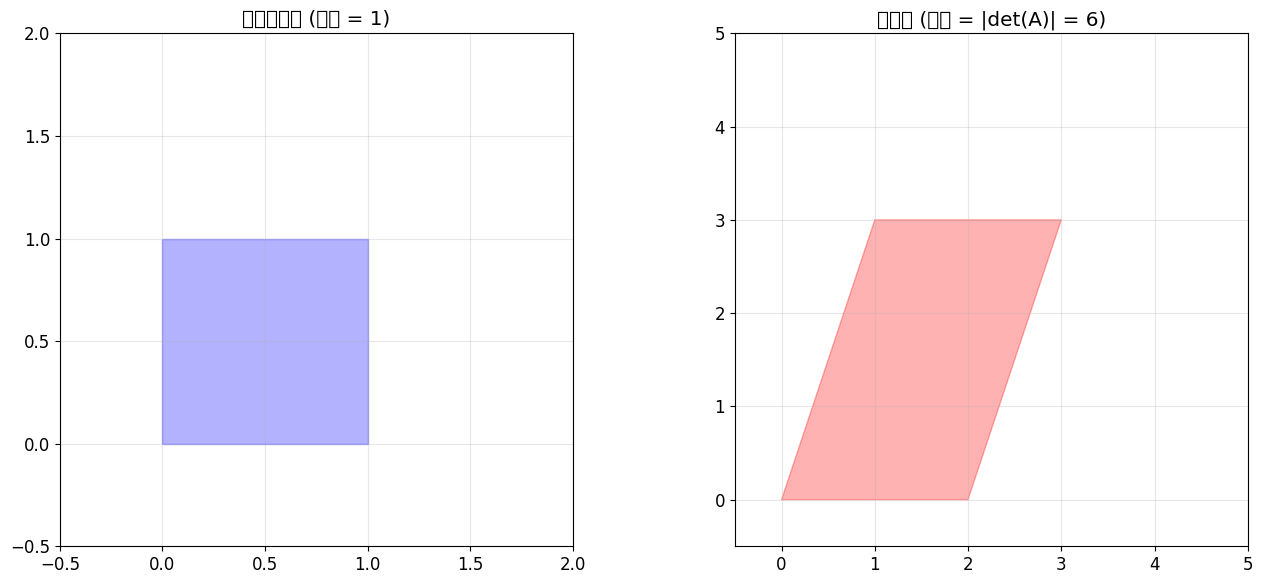

In [8]:
# 行列式的幾何意義：面積縮放
A = np.array([[2, 1], [0, 3]])
det_manual = determinant_2x2(A)
det_numpy = np.linalg.det(A)

print(f'矩陣 A =')
print(A)
print(f'det(A) 手動 = {det_manual}')
print(f'det(A) NumPy = {det_numpy}')
print(f'一致: {np.isclose(det_manual, det_numpy)} ✓')

# 視覺化：矩陣作用前後的正方形面積變化
unit_square = np.array([[0,0], [1,0], [1,1], [0,1]])
transformed = (A @ unit_square.T).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.add_patch(Polygon(unit_square, fill=True, alpha=0.3, color='blue'))
ax1.set_xlim(-0.5, 2)
ax1.set_ylim(-0.5, 2)
ax1.set_aspect('equal')
ax1.set_title(f'原始正方形 (面積 = 1)')
ax1.grid(True, alpha=0.3)

ax2.add_patch(Polygon(transformed, fill=True, alpha=0.3, color='red'))
ax2.set_xlim(-0.5, 5)
ax2.set_ylim(-0.5, 5)
ax2.set_aspect('equal')
ax2.set_title(f'變換後 (面積 = |det(A)| = {abs(det_manual):.0f})')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# 三力共面判斷
f1 = np.array([1, 0, 0])
f2 = np.array([0, 1, 0])
f3_coplanar = np.array([1, 1, 0])     # 共面（在 xy 平面）
f3_not_coplanar = np.array([1, 1, 1]) # 不共面

A_coplanar = np.array([f1, f2, f3_coplanar])
A_not = np.array([f1, f2, f3_not_coplanar])

det1 = determinant_3x3(A_coplanar)
det2 = determinant_3x3(A_not)

print(f'共面三力的行列式: {det1:.4f} → {"共面" if abs(det1) < 1e-10 else "不共面"}')
print(f'不共面三力的行列式: {det2:.4f} → {"共面" if abs(det2) < 1e-10 else "不共面"}')

共面三力的行列式: 0.0000 → 共面
不共面三力的行列式: 1.0000 → 不共面


---
## 2.5 逆矩陣

### 原理（Principle）

方陣 $A$ 的**逆矩陣** $A^{-1}$ 滿足：

$$A A^{-1} = A^{-1} A = I$$

逆矩陣存在的條件是 $\det(A) \neq 0$（即 $A$ 是非奇異矩陣）。

對於 $2 \times 2$ 矩陣，逆矩陣有簡潔的公式：

$$\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1} = \frac{1}{ad - bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

**核心思想：逆矩陣就是「反操作」**。如果 $A$ 代表一個轉換（例如旋轉 30°），那 $A^{-1}$ 就是反轉換（旋轉 $-30°$）。如果 $A$ 把向量 $\mathbf{x}$ 變成 $\mathbf{y} = A\mathbf{x}$，那逆矩陣能從 $\mathbf{y}$ 還原出 $\mathbf{x} = A^{-1}\mathbf{y}$。

重要性質：
- $(AB)^{-1} = B^{-1}A^{-1}$（順序反轉！脫衣服的順序和穿衣服相反）
- $(A^T)^{-1} = (A^{-1})^T$
- $(A^{-1})^{-1} = A$

### 直覺理解（Intuition）

想像你在 Photoshop 裡對一張圖片做了一系列操作：旋轉 45°、放大 2 倍、水平剪切。這些操作合在一起就是一個矩陣 $A$。逆矩陣 $A^{-1}$ 就是「Ctrl+Z」——按下去就能完美還原到操作之前的狀態。

但是！如果你的操作是「把圖片壓成一條線」（行列式 = 0），那就無法還原了——資訊已經永久丟失。這就是為什麼奇異矩陣沒有逆矩陣。

### 實際例子：感測器校正

假設你有一個溫度感測器系統，有兩個探頭互相之間有輕微干擾。真實溫度是 $\mathbf{x} = (100°C, 50°C)$，但感測器的讀數會有偏差：

$$\mathbf{y} = C\mathbf{x}, \quad C = \begin{bmatrix} 1.02 & 0.01 \\ 0.03 & 0.98 \end{bmatrix}$$

這裡 $C$ 是**校正矩陣**：
- 第一個探頭讀數 = $1.02 \times$ 真實溫度1 + $0.01 \times$ 真實溫度2（受到第二探頭 1% 的干擾）
- 第二個探頭讀數 = $0.03 \times$ 真實溫度1 + $0.98 \times$ 真實溫度2（受到第一探頭 3% 的干擾）

量測得到 $\mathbf{y} = (103.0, 51.7)$。要還原真實溫度，只需：

$$\mathbf{x}_{estimated} = C^{-1} \mathbf{y}$$

### 條件數（Condition Number）

**條件數** $\kappa(A) = \|A\| \cdot \|A^{-1}\|$ 衡量矩陣的「健康程度」：
- $\kappa \approx 1$：良態矩陣，逆矩陣計算穩定
- $\kappa \gg 1$：病態矩陣，微小的輸入誤差會被放大數百甚至數千倍
- $\kappa = \infty$：奇異矩陣，不可逆

實際上，如果你的感測器校正矩陣條件數很大，代表兩個探頭幾乎在量測同一件事——它們的讀數高度相關，無法有效區分兩個獨立的溫度。

### 為什麼重要（Why It Matters）

- **控制工程**：求解線性方程組 $A\mathbf{x} = \mathbf{b}$ 理論上是 $\mathbf{x} = A^{-1}\mathbf{b}$（實務中用 LU 分解更有效率）
- **機器人逆向運動學**：已知末端位置，反推各關節角度，核心是 Jacobian 矩陣的逆
- **訊號處理**：解卷積（Deconvolution）本質上是求逆運算——從模糊的訊號還原清晰的原始訊號
- **經濟學**：Leontief 投入產出模型中，$(I - A)^{-1}$ 給出各產業的總產出乘數

In [10]:
# 感測器線性校正
# 感測器模型: y = Cx + noise
# 已知 C（校正矩陣），要從量測 y 反推真實值 x

C = np.array([[1.02, 0.01], [0.03, 0.98]])  # 校正矩陣（接近單位矩陣）
x_true = np.array([100, 50])  # 真實溫度

y_measured = C @ x_true + np.array([0.5, -0.3])  # 加噪聲

# 用逆矩陣反推
C_inv = inverse_2x2(C)
x_estimated = C_inv @ y_measured

print(f'校正矩陣 C =')
print(C)
print(f'\n真實值: {x_true}')
print(f'量測值: {y_measured}')
print(f'校正後: {x_estimated}')
print(f'誤差: {np.abs(x_estimated - x_true)}')

# 驗證 C × C^{-1} = I
print(f'\nC × C⁻¹ ≈ I ? {np.allclose(C @ C_inv, np.eye(2))} ✓')

校正矩陣 C =
[[1.02 0.01]
 [0.03 0.98]]

真實值: [100  50]
量測值: [103.   51.7]
校正後: [100.49334534  49.67877514]
誤差: [0.49334534 0.32122486]

C × C⁻¹ ≈ I ? True ✓


In [11]:
# 條件數（Condition Number）分析
# 條件數越大，矩陣越「病態」，逆矩陣越不穩定

matrices = {
    '良態矩陣': np.array([[2, 0], [0, 3]]),
    '中等': np.array([[1, 0.99], [0.99, 1]]),
    '病態矩陣': np.array([[1, 0.9999], [0.9999, 1]]),
}

for name, M in matrices.items():
    cond = np.linalg.cond(M)
    det = np.linalg.det(M)
    print(f'{name}: cond = {cond:.1f}, det = {det:.6f}')

良態矩陣: cond = 1.5, det = 6.000000
中等: cond = 199.0, det = 0.019900
病態矩陣: cond = 19999.0, det = 0.000200


---
## 2.6 特殊矩陣總覽

### 原理（Principle）

工程中經常出現具有特殊結構的矩陣，利用這些結構可以大幅提升計算效率和數值穩定性。以下是最重要的幾類：

**1. 對角矩陣（Diagonal Matrix）**

$$D = \begin{bmatrix} d_1 & 0 & 0 \\ 0 & d_2 & 0 \\ 0 & 0 & d_3 \end{bmatrix}$$

每個軸獨立縮放，互不影響。逆矩陣極簡單：$D^{-1} = \text{diag}(1/d_1, 1/d_2, 1/d_3)$。
- **工程應用**：各軸獨立的慣性張量（當座標軸與主軸對齊時）。例如一個均勻圓柱體，繞對稱軸的轉動慣量和繞垂直軸的轉動慣量不同，但表示為對角矩陣。

**2. 三對角矩陣（Tridiagonal Matrix）**

$$T = \begin{bmatrix} b_1 & c_1 & & \\ a_2 & b_2 & c_2 & \\ & a_3 & b_3 & c_3 \\ & & a_4 & b_4 \end{bmatrix}$$

只有主對角線和上下各一條對角線有值。
- **工程應用**：一維有限差分法的離散矩陣。例如一根鋼棒的溫度分佈，每個節點只受到左右鄰居影響，所以矩陣只有三條對角線非零。
- **效率**：一般 $n \times n$ 矩陣需要 $O(n^3)$ 操作求解，三對角矩陣只需 $O(n)$——快了一百萬倍（$n = 10000$ 時）。

**3. 正交矩陣（Orthogonal Matrix）**

$$Q^T Q = Q Q^T = I, \quad \det(Q) = \pm 1$$

正交矩陣保持向量的長度和角度不變。$\det(Q) = +1$ 是旋轉矩陣，$\det(Q) = -1$ 是鏡射矩陣。
- **工程應用**：所有的旋轉矩陣都是正交矩陣。機器人學中描述末端姿態的旋轉矩陣 $R$ 滿足 $R^TR = I$。
- **優點**：逆矩陣就是轉置，$Q^{-1} = Q^T$，計算代價幾乎為零。

**4. 對稱正定矩陣（Symmetric Positive Definite, SPD）**

$A$ 是 SPD 若 $A = A^T$ 且對所有非零向量 $\mathbf{x}$，$\mathbf{x}^T A \mathbf{x} > 0$。
- **工程應用**：剛度矩陣 $K$（結構分析）、質量矩陣 $M$（動力學）、協方差矩陣（統計）。
- **物理意義**：$\mathbf{x}^T K \mathbf{x} > 0$ 代表「變形必須消耗正能量」，這就是彈性位能。一個穩定的結構，其剛度矩陣一定是正定的。
- **優點**：可用 Cholesky 分解 $A = LL^T$，比一般 LU 分解快 2 倍且更穩定。

**5. 稀疏矩陣（Sparse Matrix）**

大部分元素為零的矩陣。
- **工程應用**：大型有限元素模型。一個有 100 萬個節點的橋梁模型，每個節點只與附近幾十個節點相連，所以 $10^6 \times 10^6$ 的矩陣中只有不到 0.01% 的元素非零。
- **效率**：使用稀疏格式（CSR、CSC）儲存和計算，記憶體和運算時間可以從 $O(n^2)$ 降到 $O(n)$。

| 矩陣類型 | 工程對應 | 關鍵優勢 |
|---------|---------|---------|
| 對角矩陣 | 各軸獨立的慣性張量 | 逆矩陣 = 對角線取倒數 |
| 三對角矩陣 | 一維有限差分 | $O(n)$ 求解 |
| 正交矩陣 | 旋轉矩陣 | 逆 = 轉置 |
| 對稱正定 | 剛度矩陣、質量矩陣 | Cholesky 分解 |
| 稀疏矩陣 | 大型有限元素模型 | 記憶體節省 99%+ |

### 直覺理解（Intuition）

把矩陣想成一張城市地圖中的「連線表」。每個非零元素代表兩個地點之間有一條路。

- **對角矩陣**：每個地點只跟自己有關（完全獨立的孤島）
- **三對角矩陣**：像一條直線公路，每個城鎮只跟左右鄰居相連
- **稀疏矩陣**：像真實世界的公路網——城市很多，但每個城市只有幾條公路通往附近的城市
- **稠密矩陣**：像一個人數不多的群組通話——每個人都跟其他所有人直接溝通

### 實際例子：稀疏矩陣的威力

一個 $1000 \times 1000$ 的三對角矩陣：
- **稠密儲存**：$1000 \times 1000 \times 8$ bytes $= 7.8$ MB
- **稀疏儲存**：約 $3 \times 1000 \times 8$ bytes $\approx 39$ KB
- **節省**：99.5% 的記憶體

在實際的有限元素分析中，矩陣尺寸可能是 $10^6 \times 10^6$。稠密儲存需要 $8 \times 10^{12}$ bytes = 8 TB，根本放不進記憶體。但稀疏儲存只需幾 GB，完全可行。

### 為什麼重要（Why It Matters）

認識矩陣的特殊結構，是**從「能算」到「算得快」**的關鍵。在工程實務中，差別可能是「1 秒算完」和「跑了三天還沒算完」。選擇正確的矩陣儲存格式和求解器，是計算工程師最重要的技能之一。

In [12]:
# 驗證旋轉矩陣是正交矩陣
for axis in ['x', 'y', 'z']:
    R = rotation_matrix_3d(axis, np.pi/5)
    print(f'R_{axis}(36°):')
    print(f'  R^T R = I ? {np.allclose(R.T @ R, np.eye(3))}')
    print(f'  det(R) = {np.linalg.det(R):.10f}')

# 稀疏矩陣比較
from scipy.sparse import diags as sp_diags

n = 1000
K_dense = np.diag(2*np.ones(n)) + np.diag(-np.ones(n-1), 1) + np.diag(-np.ones(n-1), -1)
K_sparse = sp_diags([[-1]*n, [2]*n, [-1]*n], [-1, 0, 1], shape=(n, n), format='csr')

print(f'\n{n}×{n} 三對角矩陣:')
print(f'  Dense 記憶體: {K_dense.nbytes / 1024:.1f} KB')
print(f'  Sparse 記憶體: {(K_sparse.data.nbytes + K_sparse.indices.nbytes + K_sparse.indptr.nbytes) / 1024:.1f} KB')
print(f'  節省: {(1 - (K_sparse.data.nbytes + K_sparse.indices.nbytes + K_sparse.indptr.nbytes) / K_dense.nbytes) * 100:.1f}%')

R_x(36°):
  R^T R = I ? True
  det(R) = 1.0000000000
R_y(36°):
  R^T R = I ? True
  det(R) = 1.0000000000
R_z(36°):
  R^T R = I ? True
  det(R) = 1.0000000000



1000×1000 三對角矩陣:
  Dense 記憶體: 7812.5 KB
  Sparse 記憶體: 39.0 KB
  節省: 99.5%


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/2298405277.py:13: UserWarning: Glyph 23566 (\N{CJK UNIFIED IDEOGRAPH-5C0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/2298405277.py:13: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/2298405277.py:13: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/2298405277.py:13: UserWarning: Glyph 38499 (\N{CJK UNIFIED IDEOGRAPH-9663}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_37268/2298405277.py:13: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4j

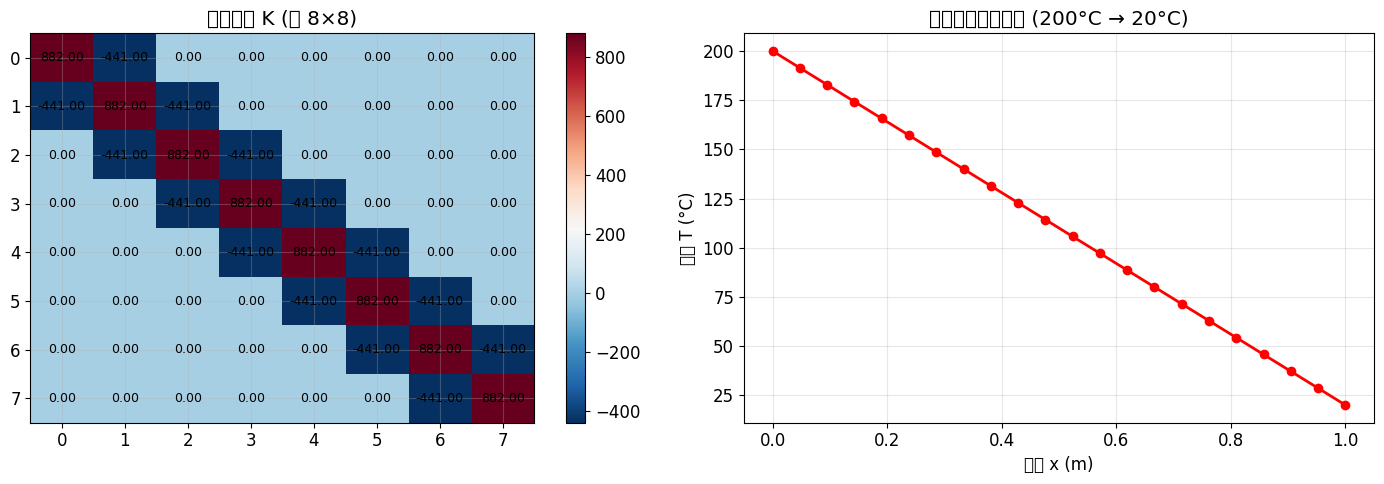


溫度分佈為線性 ✓（無內熱源時應為線性）


In [13]:
# 一維熱傳三對角矩陣建構與求解
from src.physics_models import heat_conduction_1d

x, T, K = heat_conduction_1d(n_nodes=20, T_left=200, T_right=20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_matrix_heatmap(K[:8, :8], title='導熱矩陣 K (前 8×8)', ax=ax1)
ax2.plot(x, T, 'ro-', lw=2)
ax2.set_xlabel('位置 x (m)')
ax2.set_ylabel('溫度 T (°C)')
ax2.set_title('一維穩態溫度分佈 (200°C → 20°C)')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'\n溫度分佈為線性 ✓（無內熱源時應為線性）')

---
## Module 2 驗證總結

| 項目 | 驗證方式 | 結果 |
|------|----------|------|
| 旋轉矩陣正交性 | R^T R = I, det(R) = 1 | ✓ |
| 旋轉矩陣合成 | R(θ₁)R(θ₂) = R(θ₁+θ₂) | ✓ |
| 行列式 | 手動 vs np.linalg.det | ✓ |
| 逆矩陣 | A × A⁻¹ = I | ✓ |
| 導熱矩陣對稱 | K = K^T | ✓ |
| 溫度線性分佈 | 解析解比對 | ✓ |